**Coursebook: Practical Statistics**
    
- Part of Data Science in Python Specialization for PT Freeport Indonesia
- Course Length: 12 Hours
- Last Updated: September 2025

---

Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

# Background

The coursebook is part of the **Comprehensive Data Science and Machine Learning Program** prepared by [Algoritma](https://algorit.ma/). The coursebook is intended for a restricted audience only, i.e. the individuals and organizations having received this coursebook directly from the training organization. It may not be reproduced, distributed, translated or adapted in any form outside these individuals and organizations without permission.

Algoritma is a data science education center based in Jakarta. We organize workshops and training programs to help working professionals and students gain mastery in various data science sub-fields: data visualization, machine learning, data modeling, statistical inference etc.

## Training Objectives

This coursebook is intended for participants who have completed the preceding courses.

The coursebook focuses on:

* **Descriptive Statistics**
    * **Measure of Central Tendency**
        - Mean 
        - Median
        - Mode
    * **Measure of Spread**
        - Standard Deviation
        - Variance
        - Boxplot
    * **Variable Relationship**
        - Covariance
        - Correlation
        - Scatter plot
* **Inferential Statistics**
    * **Probability Concept**
        - Normal distribution
        - Probability density function
        - Probability mass function
    * **Estimation & Confidence Interfal**
        - Central Limit Theorem (CLT)
        - Standard error and confidence interval
    * **Hypothesis Testing**
        + Z-test
        + T-test
        + ANOVA (Analysis of Variance)
        + Post Hoc Test




# Practical Statistics

Practical Statistics is an essential component of data processing that supports the business cases we aim to solve. It encompasses statistical principles widely applied in data science practices to understand and process data appropriately. In general, Practical Statistics is divided into two main categories, each of which helps us in specific ways:

- **Descriptive Statistics** 
    This category summarizes the information in the data, enabling quick retrieval of insights. The values obtained provide a summary of the dataset, aiming to describe its overall characteristics.

- **Inferential Statistics**
    This branch infers something about conditions in the field based on the available data. It seeks to generalize about the overall population based on the sample's conditions.

To fully understand each of them, we will go through several use cases. First, let's import the libraries we will use throughout this course!

In [1]:
# for data manipulation
import pandas as pd

# for statistical calculation
import numpy as np 
import math
from scipy import stats 

# for visualization purposes
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

# Study Case: Oil Production of 36 Countries (2021-2023)

[Oil Production Dataset](https://www.kaggle.com/datasets/sazidthe1/oil-production?resource=download) offers comprehensive insights into oil production across 36 countries from 2021 to 2023. With columns detailing country names, types of production, product specifications, flow information, and corresponding production values, it serves as a valuable resource for analysts, researchers, and policymakers in the energy sector. Understanding global oil production trends is critical for making informed decisions regarding energy policies, investments, and sustainability efforts.

Let's read the dataset from our `data_input` folder!

In [2]:
oil = pd.read_csv('data_input/oil_production_statistics.csv')

In [3]:
oil.head()

,country_name,type,product,flow,year,value
0,Australia,Balance,Crude oil,Industrial Production,2021,18029.678
1,Austria,Balance,Crude oil,Industrial Production,2021,561.852
2,Belgium,Balance,Crude oil,Industrial Production,2021,0.000
3,Canada,Balance,Crude oil,Industrial Production,2021,266630.180
4,Chile,Balance,Crude oil,Industrial Production,2021,340.997


The following are the descriptions for the columns.

* `country_name`: Name of the country.
* `type`: Type of statistics.
* `product`: Specification of oil production (e.g., crude, refined).
* `flow`: Oil product movement and distribution (e.g., exports, imports).
* `year`: Year of the production data.
* `value`: Production value in USD.

# Measure of Central Tendency

Often in the exploratory data analysis phase, we want to get a sense of what **the most representative score** of a particular measurement is. We often simplify this idea by referring to it as the average. However, there are, in fact, three measures of central tendency that we need to have in our statistical toolset.

## Mean and Trimmed Mean

![](assets/mean.jpg)

The most popular measure of central tendency is **the mean**, which is sometimes represented as $\bar{x}$ when computed on a sample and represented as $\mu$ when computed on a population. The mean is actually the sum of all our measurements divided by the number of measurements. Mathematically, it is written as:

$$mean = \frac{\sum{x_i}}{n}$$

To compute the mean value, we can use Pandas dataframe's built-in method: `.mean()`.

**Example: The Mean of Production Value for Crude Oil Product in Australia**

For example, let's compute the mean production value of crude oil product in Australia from 2021 to 2023! First, we need to subset the `oil` dataframe to get the data for our purpose.

In [4]:
# define the conditions
cond1 = (oil['country_name'] == 'Australia')
cond2 = (oil['product'] == 'Crude oil')

# conditional subsetting
au_crude = oil[cond1 & cond2]

In [5]:
au_crude.head(9)

,country_name,type,product,flow,year,value
0,Australia,Balance,Crude oil,Industrial Production,2021,18029.678
36,Australia,Balance,Crude oil,Industrial Production,2021,16725.052
720,Australia,Balance,Crude oil,Consumption Pattern,2021,1354.909
756,Australia,Balance,Crude oil,Consumption Pattern,2021,1301.929
1080,Australia,Balance,Crude oil,Industrial Production,2022,1469.537
1116,Australia,Balance,Crude oil,Industrial Production,2023,1345.061
1800,Australia,Balance,Crude oil,Consumption Pattern,2022,1301.929
1836,Australia,Balance,Crude oil,Consumption Pattern,2023,1566.267
2196,Australia,Balance,Crude oil,Storage Channelization,2023,170.022


In [6]:
# the average of production value for crude oil product in Australia (2021-2023)
au_crude['value'].mean()

4807.153777777778

> The average of production value for crude oil product in Australia (2021-2023) is $4807.15.

The characteristic of the mean value: sensitive to outliers. Outliers are extreme values that are far from other observations. It is less accurate to use the mean value when there are known outlier data.

> To represent data with outlier values, we can rely on the trimmed mean or the median.

If we are, in fact, required to compute the mean on data with a skewed distribution, another technique to reduce the influence of outlier data is to use a slight variation of the mean, called **the trimmed mean**. The trimmed mean removes a small designated percentage of the largest and smallest values before computing the mean. That is, before computing the trimmed mean, the data will be ordered from the smallest to the largest.

To compute the trimmed mean value, we can use  `trim_mean()` function from `stats` module of `scipy`.

**Example: The Trimmed Mean of Production Value for Crude Oil Product in Australia**

Let's use the same example as before!

Our `au_crude` data consists of 9 rows of observations. If we want to compute the 20% trimmed mean, we will remove 0.2 * 9 = 1 observation from both ends.

In [7]:
# sort values from the smallest to the largest
au_crude['value'].sort_values()

2196      170.022
756      1301.929
1800     1301.929
1116     1345.061
720      1354.909
1080     1469.537
1836     1566.267
36      16725.052
0       18029.678
Name: value, dtype: float64

The function will remove the first and the last observation, 170.022 and 18029, consecutively. Subsequently, it will compute the mean on the remaining 7 rows of data.

In [8]:
# compute 20% trimmed mean
stats.trim_mean(au_crude['value'], 0.2)

3580.669142857143

In [9]:
# manual prove

(1301.929 + 1301.929 + 1345.061 + 1354.909 + 1469.537 + 1566.267 + 16725.052)/7

3580.669142857143

## Median

![](assets/median.png)

**The median** is the value that divides the distribution into two equal halves, such that 50% of the observations are below it. To find this value, we would order the observations and locate the middle value that separates the distribution into two equal halves. It is suitable to use if outliers are present in our data or if the data has a skewed distribution. 

To compute the median value, we can use Pandas dataframe's built-in method: `.median()`.

**Example: The Median Production Value of Crude Oil Product in Australia**

Let's extend the previous example of finding a statistical summary for crude oil production value in Australia! Instead of the mean, let's summarize with the median value!

In [17]:
oil

,country_name,type,product,flow,year,value
0,Australia,Balance,Crude oil,Industrial Production,2021,18029.678
1,Austria,Balance,Crude oil,Industrial Production,2021,561.852
2,Belgium,Balance,Crude oil,Industrial Production,2021,0.000
3,Canada,Balance,Crude oil,Industrial Production,2021,266630.180
4,Chile,Balance,Crude oil,Industrial Production,2021,340.997
...,...,...,...,...,...,...
2371,Sweden,Balance,Residual fuel oil,Storage Channelization,2023,15.122
2372,Switzerland,Balance,Residual fuel oil,Storage Channelization,2023,-0.976
2373,Türkiye,Balance,Residual fuel oil,Storage Channelization,2023,80.912
2374,United Kingdom,Balance,Residual fuel oil,Storage Channelization,2023,0.000


In [14]:
# code here
# the median of production value for crude oil product in Australia (2021-2023)
oil['value'].median()

462.10749999999996

In [15]:
oil['value'].mean()

6298.349414141414

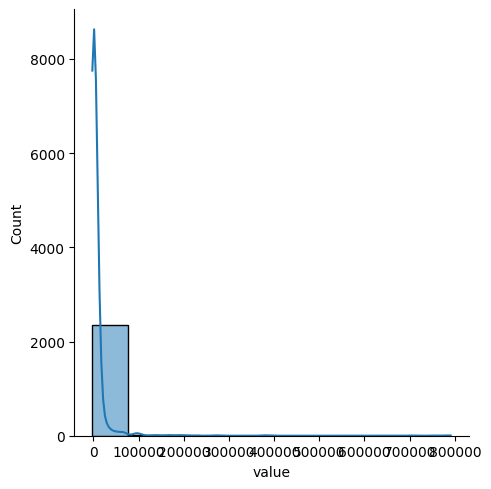

In [16]:
sns.displot(oil['value'], bins=10, kde=True)

> The median of production value for crude oil product in Australia (2021-2023) is $...

## Mode

![](assets/mode.png)

When there are discrete values for a variable, the statistical **mode** refers to the value that occurs most frequently. It is important to note that the mode is works best for categorical data.

To compute the mode value, we can use Pandas dataframe's built-in method: `.mode()`.

**Example: The Most Common Flow of Oil Products Usage in Australia**
    
For example, we want to determine the most common flow of oil products usage in Australia.

In [18]:
# define the condition
cond = (oil['country_name'] == 'Australia')

# conditional subsetting
au = oil[cond]

In [19]:
# the most common flow of oil products usage in Australia
au['flow'].mode()

0    Net Deliveries
Name: flow, dtype: object

In [ ]:
oil['country_name'].mode()

0          Australia
1            Austria
2            Belgium
3             Canada
4              Chile
5     Czech Republic
6            Denmark
7            Estonia
8            Finland
9             France
10           Germany
11            Greece
12           Hungary
13           Iceland
14           Ireland
15            Israel
16             Italy
17             Japan
18            Latvia
19         Lithuania
20        Luxembourg
21            Mexico
22       Netherlands
23       New Zealand
24            Norway
25            Poland
26          Portugal
27          Slovakia
28          Slovenia
29       South Korea
30             Spain
31            Sweden
32       Switzerland
33           Türkiye
34    United Kingdom
35     United States
Name: country_name, dtype: object

> The most common flow of oil products usage in Australia is `Net Deliveries`.

# Measure of Spread

The measure of data dispersion represents how spread out or diverse our data is. There are two common metrics in this regard: variance and standard deviation.

## Variance 

**Variance** describes how much a single numeric data spreads out from its center. Mathematically, it is written as:
    
$$var = \frac{\sum(x_i - \bar{x})^2}{n-1}$$

In nature, variance is difficult to interpret directly as it is in quadratic terms. Hence, variance ranges from 0 to infinity. The larger the value, the more variant the numerical data (the more it spreads from the mean). The variance of 0 indicates no variation in the data. 

> In higher level of understanding, you will find variance is related to the amount of information within the data.

It is important to note that variance is influenced by the data unit. Therefore, to fairly compare variance values, we must ensure that the data being compared has the same unit.

To compute the variance value, we can use Pandas dataframe's built-in method: `.var()`.

**Example: Comparing The Variance for The Production Values of United States and Finland (for Crude Oil)**

For example, let's compare the variance of the production value for crude oil in Finland and the United States! First, we need to subset the `oil` dataframe to obtain the data for our purpose.

In [21]:
# define the conditions
cond1 = (oil['country_name'] == 'United States')
cond2 = (oil['country_name'] == 'Finland')
cond3 = (oil['product'] == 'Crude oil')

# conditional subsetting
us_crude = oil[cond1 & cond3]
fin_crude = oil[cond2 & cond3]

In [22]:
us_crude.head(9)

,country_name,type,product,flow,year,value
35,United States,Balance,Crude oil,Industrial Production,2021,702512.0
71,United States,Balance,Crude oil,Industrial Production,2021,749969.0
755,United States,Balance,Crude oil,Consumption Pattern,2021,131548.0
791,United States,Balance,Crude oil,Consumption Pattern,2021,102567.0
1115,United States,Balance,Crude oil,Industrial Production,2022,63868.0
1151,United States,Balance,Crude oil,Industrial Production,2023,71118.0
1835,United States,Balance,Crude oil,Consumption Pattern,2022,102567.0
1871,United States,Balance,Crude oil,Consumption Pattern,2023,100079.0
2231,United States,Balance,Crude oil,Storage Channelization,2023,-2442.0


In [23]:
fin_crude.head(9)

,country_name,type,product,flow,year,value
8,Finland,Balance,Crude oil,Industrial Production,2021,0.0
44,Finland,Balance,Crude oil,Industrial Production,2021,0.0
728,Finland,Balance,Crude oil,Consumption Pattern,2021,1653.0
764,Finland,Balance,Crude oil,Consumption Pattern,2021,1586.0
1088,Finland,Balance,Crude oil,Industrial Production,2022,0.0
1124,Finland,Balance,Crude oil,Industrial Production,2023,0.0
1808,Finland,Balance,Crude oil,Consumption Pattern,2022,1586.0
1844,Finland,Balance,Crude oil,Consumption Pattern,2023,1198.0
2204,Finland,Balance,Crude oil,Storage Channelization,2023,85.0


In [27]:
# code here
# the variance of production value for US (crude oil product)
us_year_sum = us_crude.groupby('year')['value'].sum().reset_index()
us_year_sum.var()


year     1.000000e+00
value    7.691227e+11
dtype: float64

In [28]:
# code here
# the variance of production value for Finland (crude oil product)
fin_year_sum = fin_crude.groupby('year')['value'].sum().reset_index()
fin_year_sum.var()


year           1.0
value    1108359.0
dtype: float64

> Which country has more variation in its crude oil production value?

## Standard Deviation

**Standard deviation** is simply the square root of variance. Due to this nature, standard deviation is easier to interpret since it is in the same unit as the original data. A low or small standard deviation indicates that the data are clustered tightly around the mean, while a high or large standard deviation indicates that the data are more spread out.

$$std = \sqrt{var}$$

To compute the standard deviation value, we can use Pandas dataframe's built-in method: `.std()`.

**Example: The Standard Deviation for The Production Values of United States and Finland (for Crude Oil)**

Extending the previous example where we used `.var()`, let's now use `.std()` to compute the standard deviation for the production values of crude oil in the United States and Finland!

In [33]:
# code here 
us_year_sum['value'].std()


876996.4034135678

In [34]:
fin_year_sum['value'].std()

1052.7863031023912

## Boxplot and Histogram 

When considering the dispersion or spread of data, visualizing the distribution provides valuable insights. Two commonly used methods for visualizing data distribution are histogram and boxplot. 

### Boxplot

![](assets/boxplot.png)

**Boxplot** is made of a box and whiskers which extend from it. Some boxplots may show dots that exceed the whiskers. These dots are the outliers. 

> Outliers are the data points that are $< Q1 - 1.5IQR$ or $> Q3 + 1.5IQR$ with $IQR = Q3 - Q1$.

* If these dots present, the left outermost dot is the data minimum value and the right outermost is the data maximum value. 
* If these dots don't present, the lower and the upper part of whisker show the minimum and maximum values, respectively. 

In the meantime, Q1, Q2, Q3 are shown by the lower, middle, and upper part of box, respectively.

* Q1 represents the middle value between the median and the minimum value (25th percentile).
* Q2 represents the median (50th percentile).
* Q3 represents the middle value between the median and the maximum value (75th percentile).

From the location of Q2, we can infer about the data distribution: 

![](assets/data_distribution.png)

* A symmetrical distribution is characterized by the box being centered around the median line, with both upper and lower whiskers approximately equal in length (mean = mode = median).
* A right-skewed (positively skewed) distribution occurs when the median is nearer to the lower values of the box, and the upper whisker extends further (mean > median > mode).
* Conversely, a left-skewed (negatively skewed) distribution occurs when the median is closer to the higher values of the box, and the lower whisker extends further (mean < median < mode).

Here are some points to note regarding boxplots:

<div align="center">
<img src="assets/5number.png" width="600"/>
</div>
    
- The proportion of data from Q1 to the minimum value is 25%.
- The proportion of data from Q1 to Q2 is 25%.
- The proportion of data from Q2 to Q3 is 25%.
- The proportion of data from Q3 to the maximum value is 25%.

To generate the boxplot, we can utilize Pandas dataframe's built-in method: `.plot(kind='box')`.

**Example: The Boxplots for The Production Values of United States and Finland (for Crude Oil)**

Let's create the boxplots for the production values of crude oil between the United States and Finland (our previous example)!

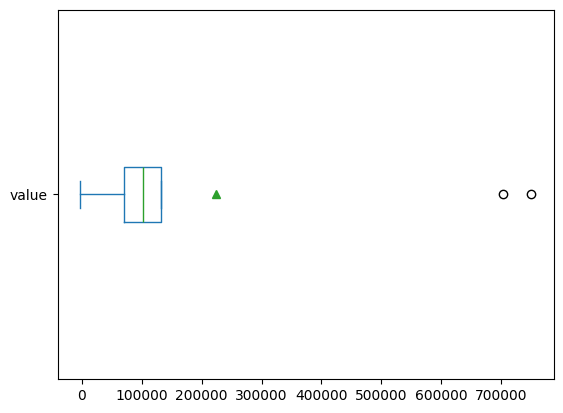

In [35]:
# US crude oil production values distribution

us_crude[['value']].plot(kind = "box", 
                    grid = False, # deactivating grid
                    showmeans = True, # show mean
                    vert = False); # horizontal orientation

<Axes: xlabel='value'>

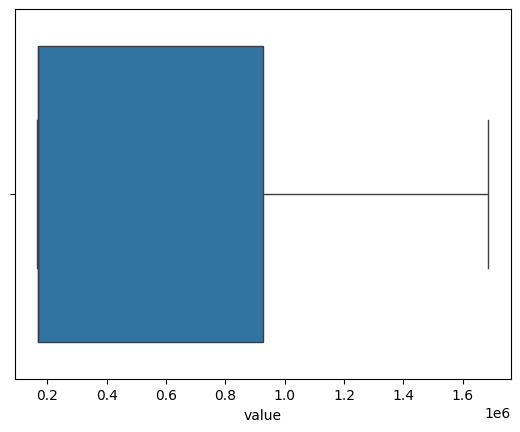

In [36]:
sns.boxplot(x=us_year_sum['value'])

> Does the data have any outliers?

> Which measure of central tendency (mean, median, mode) is appropriate for this data?

> What is the shape of the data distribution?

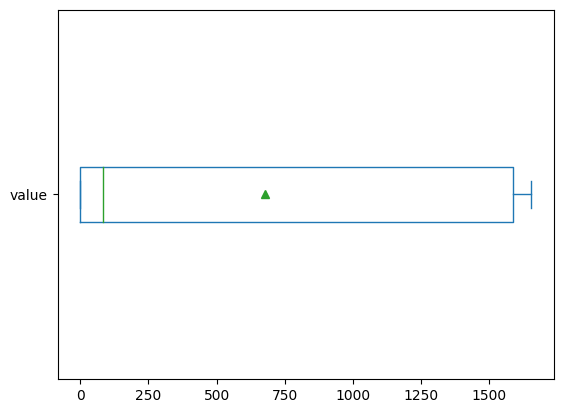

In [20]:
# Finland crude oil production values distribution

fin_crude[['value']].plot(kind = "box", 
                    grid = False, # deactivating grid
                    showmeans = True, # show mean
                    vert = False); # horizontal orientation

> Does the data have any outliers?

> Which measure of central tendency (mean, median, mode) is appropriate for this data?

> What is the shape of the data distribution?

### Histogram

Another method to visualize data distribution is by using a histogram. To generate the histogram, we can utilize Pandas dataframe's built-in method: `.plot(kind='hist')`.

**Example: The Histograms for The Production Values of United States and Finland (for Crude Oil)**

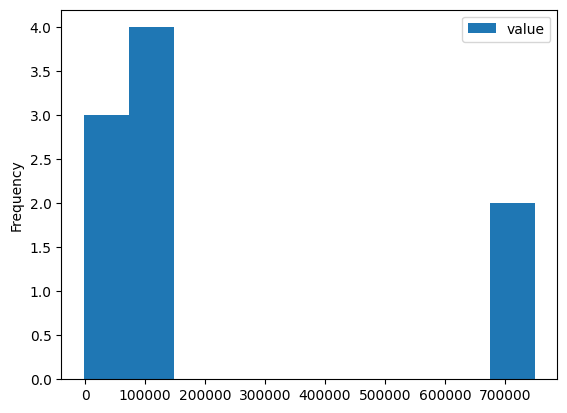

In [21]:
# US crude oil production values distribution

us_crude[['value']].plot(kind = "hist");

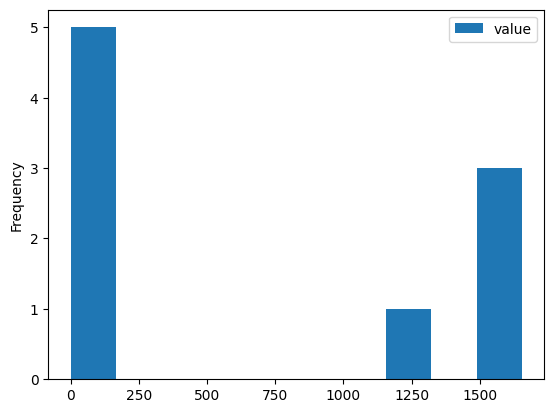

In [22]:
# Finland crude oil production values distribution

fin_crude[['value']].plot(kind = "hist");

# Study Case: Fuel Efficiency

[Auto MPG dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg) contains information about various car models from the 1970s and 1980s, along with their associated attributes and miles per gallon (MPG) ratings. This dataset is commonly used for exploring the relationships between car attributes and fuel efficiency, as well as for building predictive models to estimate a car's MPG based on its other attributes.

Let's the data from our `data_input` folder!

In [23]:
car = pd.read_csv('data_input/auto_mpg.csv')

In [24]:
car.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Here is a brief description of the attributes in the Auto MPG dataset.

-  `mpg`: miles per gallon (MPG) rating, representing the fuel efficiency of the car.
- `cylinders`: number of cylinders in the engine.
- `displacement`: engine displacement, measured in cubic inches.
- `horsepower`: horsepower rating of the engine.
- `weight`: weight of the car, measured in pounds.
- `acceleration`: acceleration time from 0 to 60 miles per hour (mph), measured in seconds.
- `model year`: model year of the car (e.g., 70 for 1970, 71 for 1971, etc.).
- `origin`: origin of the car, represented as a categorical variable (1 for American, 2 for European, 3 for Japanese).
- `car name`: name of the car model.

# Variable Relationship

In some cases, data will have many variables or columns. We want to understand the relationships between variables, especially numeric variables, in the data. There are two tools we can use to measure the linear relationship between numeric variables: covariance and correlation.

## Covariance

When we have two samples, $x$ and $y$, of the same size, then the **covariance** is an estimate of how **variation in $x$ is related to the variation in $y$**. Covariance measures how two variables covary and is represented as: 

$$Cov(x, y) = \frac{1}{n-1}\sum\limits^n_{i=1}(x_i - \mu_x)(y_i - \mu_y)$$

![](assets/covariance-positive-vs-negative.jpg)

Positive covariance values indicate movements of values in the same direction / directly proportional. Negative covariance values indicate movements of values in opposite directions. Covariance has no limit to measure the strength of the relationship between two variables (-infinity to +infinity), so we can only determine whether the relationship is positive or negative.

> To overcome this limitation, correlation comes into play.

To compute the covariance value, we can use Pandas dataframe's built-in method: `.cov()`.

**Example: The Covariance between `displacement` and `mpg`**

For example, we will compute the covariance between `displacement` and `mpg`.

In [25]:
car[['displacement','mpg']].cov()

,displacement,mpg
displacement,10872.199152,-655.402318
mpg,-655.402318,61.089611


> From the code above, we get the value of -655.40, which indicates that both variables move in opposite directions.

## Correlation

Correlation compresses the covariance values from -infinity to +infinity into **-1 to 1**. It is allowing us to measure the strength of the relationship between the data (variables). Mathematically, correlation can be expressed as:

$$Cor(x, y) = \frac{Cov(x,y)}{\sqrt{Var(x)Var(y)}}$$

Correlation values indicate the strength of the relationship between two numerical variables as follows.
   
![](assets/correlation-coef.jpg)

* When the correlation between two numerical variables approaches:
  - -1, it means a strong negative correlation.
  - 0, it means no correlation.
  - 1, it means a strong positive correlation.

To compute the correlation value, we can use Pandas dataframe's built-in method: `.corr()`.

**Example: The Correlation between `displacement` and `mpg`**

For example, we will compute the correlation between `displacement` and `mpg`.

In [26]:
car[['displacement','mpg']].corr()

,displacement,mpg
displacement,1.000000,-0.804203
mpg,-0.804203,1.000000


> From the code above, we get the value of -0.8042. What is your interpretation about these variables relationship?

## Scatterplot

Aside from correlation, we can visually inspect the extent of the linear relationship between variables by plotting them together using a scatterplot. We can use a scatterplot to plot numerical variables. Below is an overview of each correlation indication based on scatterplot visualization.

![](assets/correlation.png)

To generate the scatterplot, we can utilize Pandas dataframe's built-in method: `.plot(kind='scatter')`.

**Example: The Scatterplot between `displacement` and `mpg`**

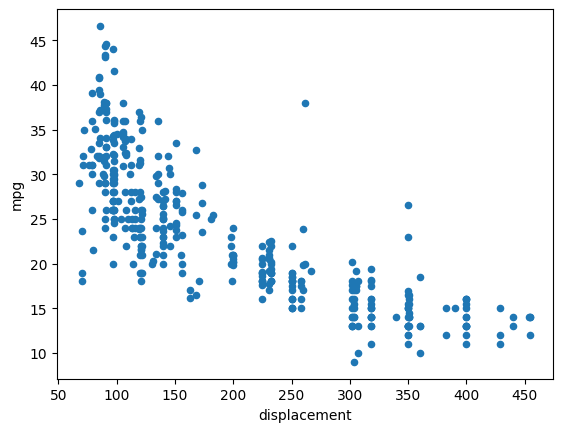

In [27]:
car[['displacement','mpg']].plot(kind = 'scatter',
                                x = 'displacement',
                                y = 'mpg');

# Inferential Statistics

**Inferential statistics** helps us draw conclusions about the entire data (population) by using only a portion of its information (sample).

![](assets/statistical_cycle.png)

## Normal Distribution

Another way to study the center and spread of data is through a curve. This curve is often used to represent how data is spread out, and the most famous of all these curves is **the normal curve**.

![](assets/normal-distribution.jpg)

A normal distribution with a mean of 0 and a standard deviation of 1 is called a **standard normal curve**. When a measurement follows a standard normal distribution, we can use the assumptions of a normal distribution for the data. These assumptions are fully described by two parameters: the mean and the standard deviation. The empirical rule of a standard normal gives us the following:

- 68% of the data will fall within 1 standard deviation of the mean.
- 95% of the data will fall within 2 standard deviations of the mean.
- 99.7% of the data will fall within 3 standard deviations of the mean.

Looking at the illustration above, the normal distribution is bell-shaped (perfectly symmetrical, with mean = median = mode), unimodal (having only a single mode), and the area under the curve is 1.

One important idea related to the normal distribution is known as the **Central Limit Theorem**. It states that when we have many independent variables generated by various distributions, the total of those variables will tend toward a normal distribution, assuming no extraordinary interventions. This universality is observed across different fields, making the normal distribution a fundamental aspect of applied statistics and mathematics.

This distribution plays crucial roles in statistical inference, including:

1. **Calculating Probability**
    - Probability Mass Function (for discrete/categorical variables).
    - Probability Density Function (for continuous/numeric variables).
2. **Creating Confidence Intervals**
3. **Hypothesis Testing**

We will explore each of these applications in the following chapters.

## Probability Mass Function

Discrete random variables (number of player injury, amount of defaulted loans, travel bookings per customer) can be described using a **probability mass function**, which maps each value of the random variable to a probability:  
- p(0 bookings) = 0.28  
- p(1 booking) = 0.09  
- …  
- p(6 bookings) = 0.004  

To calculate the probability of a discrete event among several possible outcomes, we just divide the number of desired events by the total number of events. The probabilities of all possible outcomes will add up to 1.

**Example: The Probability of a Car Originating from America**

For example, the probability of a car originating from America is calculated as follows.

In [28]:
# frequency table
car['origin'].value_counts()

1    249
3     79
2     70
Name: origin, dtype: int64

In [29]:
# probability a car originating from America

249/(249+79+60)

0.6417525773195877

> The probability a car originating from America is 64.17%.

**Example: The Probability of a Car being Produced in 1978**

> What is the probability of a car that was produced in 1978?

In [30]:
# code here



## Probability Density Function

When we're considering continuous random variables (such as blood sugar level, height, or rainfall amount), it's important to recognize that these variables have an infinite number of possible values, even between two real intervals. The resulting probability distribution of the variable can be described by a **probability density function**, where the probability is determined by calculating the area under the curve.

![](assets/pdf.png)

To calculate the probability from a probability density function, we need to follow these steps:

1. Compute the z-score (convert the original data to a standard normal distribution using z-score standardization). Below is the formula of the z-score.
$$Z = \frac{x-\mu}{\sigma}$$

   Where:
   * $x$: the value we want to standardize.
   * $\mu$: the mean of the data.
   * $\sigma$: the standard deviation of the data.
2. Compute the probability based on the z-score using the `cdf()` function.

Consider the following scenario:

The height of men in Indonesia is normally distributed with a mean of 160cm and a standard deviation of 7cm. What is the probability of a randomly selected man being taller than 175cm?

In [31]:
# compute the z-score
Z = (175-160)/7
# compute the probability of being shorter than 175 cm  
p = stats.norm.cdf(Z)

In [32]:
# compute the probability of being taller than 175 cm 
print(1-p)

0.016062285603828275


> The probability of men being taller than 175 cm is 1.6%.

**Example: The Probability of an `mpg` Value being between 20 and 30**

> What is the probability of an `mpg` value being between 20 and 30?

/opt/miniconda3/envs/freeport_ds/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


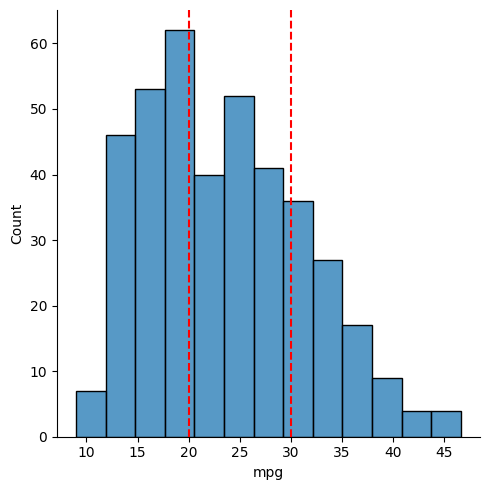

In [33]:
sns.displot(car['mpg'])
plt.axvline(20, color='r', linestyle='--')
plt.axvline(30, color='r', linestyle='--');

In [34]:
# code here


The z-scores we used above are useful when relating different measurement distributions to each other, acting as a common denominator. Essentially, a z-score gives us a "standardized" unit that measures how many standard deviations a particular statistic is away from the mean. This property, as we'll see, is paramount to many statistical hypothesis tests, performance evaluations (more on that when we get to the Machine Learning courses), and in the construction of confidence or prediction intervals.

## Standard Error and Confidence Interval

**Standard error (SE)** is a measure that estimates how close a calculated mean (sample) is likely to be to the true mean of that population. SE measures the goodness of the sample in representing the population. The smaller it is, the more representative (better) the sample is. It is calculated by dividing the standard deviation of the sample data by the square root of the number of observations. Below is the formula for standard error.

$$SE=\frac{\sigma}{\sqrt{}n}$$

Where:
   * $SE$: the standard error.
   * $\sigma$: the standard deviation of the data.
   * $n$: the number of observations in the data.

For example, let's compute the standard error for the `mpg` value.

In [35]:
standard_error = car['mpg'].std()/np.sqrt(len(car['mpg']))
standard_error

0.3917798927426896

Additionally, we can compute the standard error using the `sem()` function from the `stats` library. We only need to pass the data for which we want to calculate the standard error. This function will compute the standard error based on the aforementioned formula.

In [36]:
stats.sem(car['mpg'])

0.3917798927426896

The standard error of a mean provides a statement of probability about the difference between the mean of the population and the mean of the sample. We often begin our estimation with a point estimate, using, for example, the sample mean $\bar{x}$ as a point estimate of the population mean $\mu$. We can then construct **confidence intervals** around our point estimates so that we have an interval that may contain the true value of the parameter. When statisticians talk about a "95% confidence interval," what they mean is that if we create 100 confidence intervals of the same size from a given population, we expect to find the true parameter (let's say the population’s net savings per household) in 95 of them.

We construct a confidence interval by taking the point estimate plus or minus the margin of error, where the margin of error is computed as:

$$E=Z_{\frac{a}{2}} * SE$$

where:
    
   * $E$: the margin error.
   * $Z_{\frac{a}{2}}$: the z-score of $\frac{a}{2}$.
   * $SE$: the standard error.

Because confidence intervals are two-sided, the level of significance we choose ($\alpha$) has to be divided into halves. When we compute by finding the z-score associated with a value of 2.5% (0.025) on each end, we end up looking at the middle 95% of the area under the curve. We can use `ppf()` from the `scipy` package to help us find the z-score associated with a 95% confidence interval.

In [37]:
stats.norm.ppf(.025) # 95% confidence interval

-1.9599639845400545

In short, confidence intervals are the intervals in which we believe the population parameters present. To compute confidence interval, we will do the following steps.

* Determine the mean of the sample.
* Determine the standard deviation of the sample and standard error.
* Determine the significance level ($\alpha$) (1 - the confidence level).
  > The most common values for the significance level are 1%, 5%, and 10%.
* Determine $Z_{\alpha/2}$.
* Determine the confidence interval. Below is the formula for the confidence interval.

  $$CI = \bar{x} \pm Z_{\frac{\alpha}{2}}*SE$$
  
  Where:
  * $CI$: the confidence interval.
  * $\bar{x}$: the mean value.
  * $Z_{\frac{\alpha}{2}}*SE$: the margin error.

**Example: The Confidence Interval of `mpg`**

For example, we want to estimate the confidence interval of the `mpg` value.

In [38]:
# mean of the sample
mean = car['mpg'].mean()
mean

23.514572864321607

In [39]:
# standard deviation of the sample
std = car['mpg'].std()
std

7.815984312565782

In [40]:
# standard error
SE = std/np.sqrt(len(car['mpg']))
SE

0.3917798927426896

In [41]:
# choose the significance level
alpha = 0.05

In [42]:
# determine Z_alpha/2

Z = stats.norm.ppf(alpha/2)
Z

-1.9599639845400545

In [43]:
# lower bound

lower_bound = mean - (abs(Z) * SE)
lower_bound

22.74669838467897

In [44]:
# upper bound

upper_bound = mean + (abs(Z) * SE)
upper_bound

24.282447343964243

> With a confidence level of 95%, the average mean interval for `mpg` is in the interval from 22.74 to 24.28.

## Hypothesis Testing

In our day to day data science work, you will often be required to explain the model's reliability and uncertainty, and the formal process of such is specified as something called the **test of significance**. Statistical significance often reference the **p-value**, a measure of the probability of obtaining a result equal to or more extreme than what was actually observed, assuming the null hypothesis is true. 

The hypothesis serves as the foundation of the testing process. It's a tentative statement about a population parameter (like the average income or the effectiveness of a new drug) that we aim to test. There are two key hypotheses involved:

- Null Hypothesis ($H_0$): This represents the initial assumption, often reflecting the status quo or no change due to the treatment. The null hypothesis typically incorporates an element of similarity, using symbols like "equals" (=), "greater than or equal to" (≥), or "less than or equal to" (≤).
- Alternative Hypothesis ($H_1$): This hypothesis stands in opposition to the null hypothesis. It suggests that a difference or effect exists, contradicting the null hypothesis's assertion of no change.

Before conducting the test, we establish a significance level ($\alpha$). This value, often set at 0.05, represents the tolerable error rate. The confidence level is intricately linked to the significance level. It's calculated as ($1-\alpha$) and represents the level of confidence we have in our conclusion.  For instance, a 95% confidence level indicates that we are 95% confident that the interval we construct captures the true population parameter. The hypothesis testing process involves conducting a statistical test on the sample data. This test generates a p-value, which signifies the probability of observing sample data as extreme (or more extreme) as the one we obtained, assuming the null hypothesis ($H_0$) is true. The p-value plays a critical role in interpreting the test results. Here's the decision rule:

- If the p-value is less than $\alpha$ **(p-value < $\alpha$)**: We reject the null hypothesis ($H_0$). This suggests that the evidence from the sample data is strong enough to cast doubt on the initial assumption ($H_0$) and supports the alternative hypothesis ($H_1$). There's a statistically significant effect.
- If the p-value is greater than $\alpha$ **(p-value > $\alpha$)**: We fail to reject the null hypothesis ($H_0$). In this scenario, the sample data doesn't provide sufficient evidence to refute the initial assumption ($H_0$). It's important to remember that failing to reject $H_0$ doesn't necessarily imply $H_0$ is true; it simply means we lack the evidence to disprove it with the chosen significance level.

![](assets/p-value.png)

**Example of Hypothesis**

1. Two-way hypothesis (!=)

- $H_0$ : The average oil production per well is not significantly different between wells drilled using Technique A and Technique B. (=)
- $H_1$ : The average oil production per well is **significantly** different between wells drilled using Technique A and those drilled using Technique B. (!=)

2. One-way hypothesis (<)

- $H_0$ : The introduction of a new drilling fluid does not affect the drilling speed (>=)
- $H_1$ : The introduction of a new drilling fluid **decreases** the drilling speed (<)

3. One-way hypothesis (>)

- $H_0$: The implementation of a new well completion technique does not affect the well productivity (<=)
- $H_1$: The implementation of a new well completion technique **increases** the well productivity (>)

Below, we will discuss two types of hypothesis tests that are often used, namely z-test and t-test.

### Z-Test

The z-test offers a robust statistical tool for hypothesis testing in the oil and gas industry when the population standard deviation is known and the sample size is large (n > 30). The following are the steps to conduct a z-test:

* Determine the null $H_0$ and alternative $H_1$ hypotheses.
* Determine the significance level ($\alpha$).
* Determine the mean and standard deviation of the population, the sample size, and the mean of the sample.
* Calculate the standard error (SE) and z value:
    $$SE = \frac{\sigma}{\sqrt{n}}$$
    $$Z = \frac{\bar{X} - \mu}{SE}$$
* Determine the p-value.
* Compare the p-value and alpha:
    * If the p-value < $\alpha$, then reject $H_0$.
    * If the p-value > $\alpha$, then fail to reject $H_0$.

**Example**

To better understand the z-test, consider the following scenario:

Suppose the average production rate of natural gas from a certain field is **2000** cubic meters per day, with a standard deviation of **500** cubic meters per day. In an effort to improve production efficiency, a new drilling technique was implemented. After implementing the new technique, **30** random wells were selected, which had an average production rate of **2200** cubic meters per day.

As an oil and gas company, you need to analyze whether the new drilling technique significantly increases production rates or not. Use a confidence level of **95%** to determine the significance of the results.

**Step 1: Null and Alternative Hypotheses**

$H_0$: The average production rate of natural gas using the new drilling technique is not significantly different from 2000 cubic meters per day.

$H_1$: The average production rate of natural gas using the new drilling technique is significantly higher than 2000 cubic meters per day.

In [45]:
# step 2

alpha = 0.05

In [46]:
# step 3

mean_pop = 2000
std_pop = 500
n = 30
mean_smp = 2200

In [47]:
# step 4

SE = std_pop/np.sqrt(n)
Z = (mean_smp - mean_pop)/SE

In [48]:
# step 5

p = 1 - stats.norm.cdf(Z)

In [49]:
# step 6

print("Z-score:", Z)
print("P-value:", p)

Z-score: 2.1908902300206643
P-value: 0.014229868458155326


In [50]:
p > alpha

False

> p-value is smaller than $\alpha$. Hence, we reject $H_0$.

### T-Test

Generally, z-tests are used when we have a large enough sample size (rule of thumb is n >= 30) and when the population standard deviation is known. If the above conditions aren't met, we can instead use a statistical measurement known as the **Student's t-test**. The shape of the t-distribution is similar to the normal distribution, except that it is more sloping when the number of samples is small.

![](assets/t-distribution.jpg)

**Example**

To better understanding about t-test consider the following scenario: 

An oil company is evaluating the effectiveness of two different drilling techniques: Technique A and Technique B. 

In [51]:
production_rate_technique_a = pd.Series([2000, 2100, 2050, 1980, 2150, 2050, 2025, 2075, 2100, 1950])
production_rate_technique_b = pd.Series([2025, 2075, 1980, 2150, 2125, 2080, 2050, 2100, 1950, 1975])

The company wants to determine if there is a significant difference in the average production rates between wells drilled using Technique A and those drilled using Technique B.

**I. Specify The Hypothesis**

- $H_0$: There is no significant difference in the average production rates between wells drilled using Technique A and those drilled using Technique B.
- $H_1$: There is a significant difference in the average production rates between wells drilled using Technique A and those drilled using Technique B.

**II. Calculate p-value with `ttest_ind()`**

Use the `ttest_ind()` function to calculate the t-statistics and p-value of two independent samples.

```python
t_stats, pval = ttest_ind(a= ...,
                          b= ...,
                          alternative = ...)
```

Parameters:

- `a` : data or sample observations in Series or array form.
- `b` : data or sample observations in Series or array form.
- `alternative` : depends on hypothesis alternative ($H_1$).
    - if $H_1$ is not equal (!=) to a certain value, fill with `two-sided`.
    - if $H_1$ is greater (>) than the specified value, fill with `less`.
    - If $H_1$ is greater (<) than the specified value, fill with `greater`.

In [52]:
# t-test
t_stats, pval = stats.ttest_ind(a=production_rate_technique_a,
                                b=production_rate_technique_b,
                                alternative='two-sided')

pval

0.9180523884060912

> With $\alpha = 0.05$, the p-value is greater than $\alpha$. In this case, we fail to reject $H_0$.

### ANOVA (Analysis of Variance)

The **Analysis of Variance (ANOVA)** is a statistical method used to test whether there are significant differences between the means of three or more independent groups. While the t-test is limited to comparing two groups, ANOVA extends this concept, making it especially useful in industrial applications where multiple processes, treatments, or methods are tested simultaneously.

In the mining industry, ANOVA can be used to compare the efficiency of different extraction methods, equipment types, or blasting techniques across multiple mining sites. The test works by analyzing the ratio of variance between the groups to the variance within the groups.

**Steps in ANOVA**

1. Formulate hypotheses:

   * \$H\_0\$: All group means are equal.
   * \$H\_1\$: At least one group mean is significantly different.

2. Choose a significance level (\$\alpha\$).

3. Calculate the F-statistic:
   $F = \frac{\text{Variance Between Groups}}{\text{Variance Within Groups}}$

4. Determine the p-value based on the F-distribution.

5. Decision rule:

   * If p-value < \$\alpha\$, reject \$H\_0\$ (at least one group mean differs).
   * If p-value > \$\alpha\$, fail to reject \$H\_0\$ (no significant difference detected).


**Example**

A mining company is testing three different types of drilling machines (Machine A, Machine B, Machine C) to evaluate which one provides the highest average coal extraction rate (in tons/day). The production results from randomly selected drilling operations are as follows:

In [53]:
machine_a = [102, 98, 105, 100, 97]
machine_b = [110, 115, 108, 112, 109]
machine_c = [95, 92, 98, 94, 96]

**I. Specify the hypothesis**

* \$H\_0\$: The average extraction rates are the same across Machine A, B, and C.
* \$H\_1\$: At least one machine has a different average extraction rate.

**II. Run ANOVA**

In [54]:
f_stat, pval = stats.f_oneway(machine_a, machine_b, machine_c)
f_stat, pval

(42.0608695652175, 3.7858007848817186e-06)

**III. Interpretation**

Suppose the output is:

In [58]:
F_statistic = 35.2
p_value = 0.0001

Since p-value < 0.05, we reject \$H\_0\$. This indicates that there is a statistically significant difference in average coal extraction rates among the machines.


### Post Hoc Test

ANOVA tells us that a difference exists but does not specify *which* groups differ. To find out exactly where the differences lie, we conduct a **Post Hoc Test**.

In mining operations, this is critical: knowing that machines differ is useful, but identifying *which machine outperforms the others* is far more actionable for decision-making.

**Common Post Hoc Tests**

* **Tukey’s HSD (Honestly Significant Difference):** Compares all pairs of groups to see which ones differ significantly.
* **Bonferroni correction:** Adjusts significance levels to reduce the risk of false positives when multiple comparisons are made.
* **Dunnett’s Test:** Compares multiple groups against a single control group.


**Example**

Continuing from the ANOVA scenario, suppose we want to know *which drilling machine* is better.

In [59]:
# combine data
data = machine_a + machine_b + machine_c
groups = ['A']*len(machine_a) + ['B']*len(machine_b) + ['C']*len(machine_c)

In [60]:
df = pd.DataFrame({'extraction': data, 'machine': groups})

In [62]:
# Tukey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['extraction'],
                          groups=df['machine'],
                          alpha=0.05)

In [64]:
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     A      B     10.4 0.0002   5.7281  15.0719   True
     A      C     -5.4 0.0239 -10.0719  -0.7281   True
     B      C    -15.8    0.0 -20.4719 -11.1281   True
------------------------------------------------------


**Interpretation:**

The Tukey test results will show pairwise comparisons:

* Machine A vs Machine B
* Machine A vs Machine C
* Machine B vs Machine C

If the adjusted p-value < 0.05 for a pair, it means those two machines have significantly different average extraction rates.

For example, if Machine B significantly outperforms both A and C, the company should consider prioritizing Machine B for operations.

### Summary

In this course, we delved into Practical Statistics, covering a range of topics from central tendency and spread measures to understanding variable relationships.

In the section on central tendency measures, we explored the concept of the mean. Recognizing its sensitivity to outliers, we investigated alternative measures like the trimmed mean and median. Additionally, we examined descriptive statistics for categorical variables, such as the mode.

Shifting to spread measures, we discussed variance and standard deviation, along with their advantages and limitations. We also explored visualization techniques like boxplots and histograms to assess spread. Boxplots helped identify outliers and drew conclusions about data distribution based on their characteristics. Additionally, we clarified data distribution through histograms.

We explored variable relationships through covariance and correlation. Scatterplots provided a visual representation of variable movement direction.

Finally, we dived into inferential statistics, focusing mainly on the implementation of the normal distribution: calculate probability, determine confidence intervals, and conduct hypothesis testing.